# Word2Vec Tutorial with Gensim

In [28]:
# !pip install gensim

In [403]:
# imports

import json
from collections import Counter
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import utils
from nltk.tokenize import word_tokenize

%matplotlib inline

Data pre-processing to make it readable by json.load()

In [296]:
# Load and display data

with open('countries.json', 'r', encoding='utf-8') as fout:
    countries = json.load(fout)

In [300]:
countries.keys()

dict_keys(['Afghanistan', 'land Islands', 'Albania', 'Algeria', 'American Samoa', 'AndorrA', 'Angola', 'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Bouvet Island', 'Brazil', 'British Indian Ocean Territory', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China', 'Christmas Island', 'Cocos (Keeling) Islands', 'Colombia', 'Comoros', 'Congo', 'Congo, The Democratic Republic of the', 'Cook Islands', 'Costa Rica', 'Cote D"Ivoire', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Ethiopia', 'Falkland Island

In [299]:
print(''.join(countries['India'])[:512] + ' ...')

India, officially the Republic of India, is a country in South Asia.  It is the seventh-largest country by area; the most populous country from June 2023 onwards; and since its independence in 1947, the world's most populous democracy. Bounded by the Indian Ocean on the south, the Arabian Sea on the southwest, and the Bay of Bengal on the southeast, it shares land borders with Pakistan to the west; China, Nepal, and Bhutan to the north; and Bangladesh and Myanmar to the east. In the Indian Ocean, India is n ...


In [302]:
for i, (country, text) in enumerate(countries.items()):
    print(country)
    print(''.join(text)[:512] + ' ...')
    print('-' * 100)
    if i >= 5:
        break

Afghanistan
Afghanistan, officially the Islamic Emirate of Afghanistan, is a landlocked country located at the crossroads of Central Asia and South Asia. It is bordered by Pakistan to the east and south, Iran to the west, Turkmenistan to the northwest, Uzbekistan to the north, Tajikistan to the northeast, and China to the northeast and east. Occupying 652,864 square kilometers (252,072 sq mi) of land, the country is predominantly mountainous with plains in the north and the southwest, which are separated by the Hindu K ...
----------------------------------------------------------------------------------------------------
land Islands
Wikipedia page not found. ...
----------------------------------------------------------------------------------------------------
Albania
Albania (  a(w)l-BAY-nee-ə; Albanian: Shqipëri or Shqipëria), officially the Republic of Albania (Albanian: Republika e Shqipërisë), is a country in Southeast Europe. It is located in the Balkans, on the Adriatic and I

In [404]:
corpus = []
for text in list(countries.values()):
    corpus.append(word_tokenize(text))

In [406]:
corpus[0]

['Afghanistan',
 ',',
 'officially',
 'the',
 'Islamic',
 'Emirate',
 'of',
 'Afghanistan',
 ',',
 'is',
 'a',
 'landlocked',
 'country',
 'located',
 'at',
 'the',
 'crossroads',
 'of',
 'Central',
 'Asia',
 'and',
 'South',
 'Asia',
 '.',
 'It',
 'is',
 'bordered',
 'by',
 'Pakistan',
 'to',
 'the',
 'east',
 'and',
 'south',
 ',',
 'Iran',
 'to',
 'the',
 'west',
 ',',
 'Turkmenistan',
 'to',
 'the',
 'northwest',
 ',',
 'Uzbekistan',
 'to',
 'the',
 'north',
 ',',
 'Tajikistan',
 'to',
 'the',
 'northeast',
 ',',
 'and',
 'China',
 'to',
 'the',
 'northeast',
 'and',
 'east',
 '.',
 'Occupying',
 '652,864',
 'square',
 'kilometers',
 '(',
 '252,072',
 'sq',
 'mi',
 ')',
 'of',
 'land',
 ',',
 'the',
 'country',
 'is',
 'predominantly',
 'mountainous',
 'with',
 'plains',
 'in',
 'the',
 'north',
 'and',
 'the',
 'southwest',
 ',',
 'which',
 'are',
 'separated',
 'by',
 'the',
 'Hindu',
 'Kush',
 'mountain',
 'range',
 '.',
 'Kabul',
 'is',
 'the',
 'country',
 "'s",
 'capital',
 '

## Basic Word2Vec Usage

In [407]:
# Create and train a simple model

model = Word2Vec(sentences= corpus)

### Word2Vec options

In [392]:
# Word2Vec?

In [408]:
model.corpus_total_words

2702713

In [412]:
model.wv.most_similar(['India'], topn= 5)

[('Sudan', 0.8424902558326721),
 ('Russia', 0.7916614413261414),
 ('Turkey', 0.781129002571106),
 ('Arabia', 0.7789273858070374),
 ('Mozambique', 0.7664263248443604)]

## Heuristics for Word2vec algorithms

### Determining size of the vocabulary

In [414]:
# How many unique words in the vocabulary?

counter = Counter()
for words in countries.values():
    for word in words:
        counter.update([word])

print(len(counter))

1014


In [415]:
counter

Counter({' ': 2294276,
         'e': 1355039,
         'a': 1039727,
         't': 973545,
         'n': 937090,
         'i': 929267,
         'o': 841515,
         'r': 775517,
         's': 707896,
         'l': 487657,
         'h': 479604,
         'd': 437713,
         'c': 373516,
         'u': 324712,
         'm': 281655,
         'f': 234416,
         'p': 226361,
         'g': 213396,
         'y': 171413,
         ',': 161948,
         'b': 145423,
         'w': 140782,
         '.': 124158,
         'v': 117911,
         '0': 73559,
         '1': 65598,
         '\n': 55877,
         'k': 54520,
         'A': 53593,
         'T': 52826,
         '2': 52511,
         'S': 50796,
         'C': 44766,
         'I': 40705,
         'M': 34046,
         '9': 33933,
         'P': 30889,
         'B': 28382,
         '-': 25365,
         ')': 24208,
         '(': 24203,
         'E': 23669,
         'N': 22556,
         'F': 21915,
         'x': 21145,
         'G': 20937,
      

In [416]:
# Default vocabulary size of the original model

len(model.wv)

22724

Loss after epoch 0: 1603668.875
Loss after epoch 1: 1264406.875
Loss after epoch 2: 1140750.25
Loss after epoch 3: 951683.5
Loss after epoch 4: 897077.5
Loss after epoch 5: 879109.5
Loss after epoch 6: 854680.0
Loss after epoch 7: 838940.5
Loss after epoch 8: 712021.0
Loss after epoch 9: 719478.0


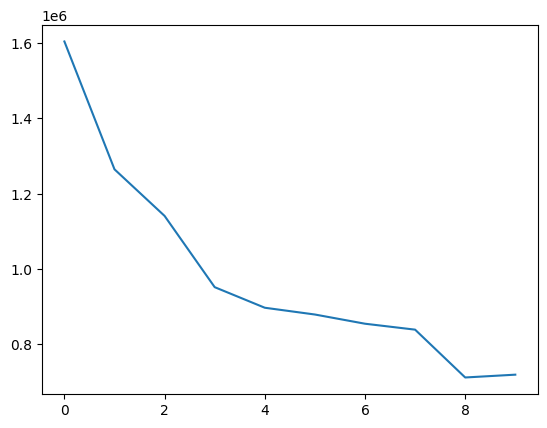

In [417]:
# Retrain - increased vocabulary size, more epochs, larger word vectors

metric = utils.MetricCallback(every=1)
model = Word2Vec(
    sentences= corpus,
    vector_size=128,
    epochs=10,
    max_vocab_size=65536,
    compute_loss=True,
    callbacks=[metric]
)
plt.plot(metric.myloss)

In [418]:
# Check similarities again

model.wv.most_similar('India')

[('China', 0.6782056093215942),
 ('Pakistan', 0.6612791419029236),
 ('Sudan', 0.6313547492027283),
 ('Indonesia', 0.6196268200874329),
 ('Japan', 0.6087499260902405),
 ('Vietnam', 0.5973421335220337),
 ('Korea', 0.5882426500320435),
 ('Asia', 0.5867118835449219),
 ('Far', 0.5801216959953308),
 ('Timor', 0.5730212330818176)]

Loss after epoch 0: 563584.625
Loss after epoch 10: 322080.25
Loss after epoch 20: 241308.5
Loss after epoch 30: 230791.0
Loss after epoch 40: 224757.0
Loss after epoch 50: 225998.0
Loss after epoch 60: 216615.0
Loss after epoch 70: 170586.0
Loss after epoch 80: 169628.0
Loss after epoch 90: 152674.0


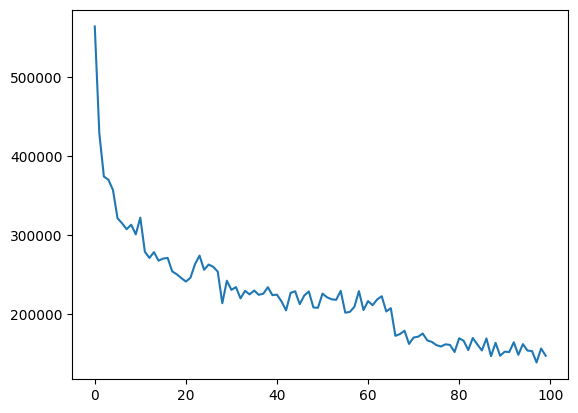

In [419]:
# Retrain - more epochs

metric = utils.MetricCallback(every=10)
model = Word2Vec(
    sentences= corpus,
    vector_size=128,
    epochs=100,
    max_vocab_size=65536,
    compute_loss=True,
    callbacks=[metric],
    min_alpha=0.001,
    workers=9
)
plt.plot(metric.myloss)

In [420]:
model.wv.most_similar('India')

[('China', 0.6277143955230713),
 ('Pakistan', 0.6119533777236938),
 ('Indonesia', 0.5933302640914917),
 ('Nepal', 0.5589773058891296),
 ('Singapore', 0.5478624701499939),
 ('Africa', 0.531823456287384),
 ('Bhutan', 0.5204789042472839),
 ('Thailand', 0.5159927010536194),
 ('Vietnam', 0.514426589012146),
 ('Japan', 0.5029564499855042)]

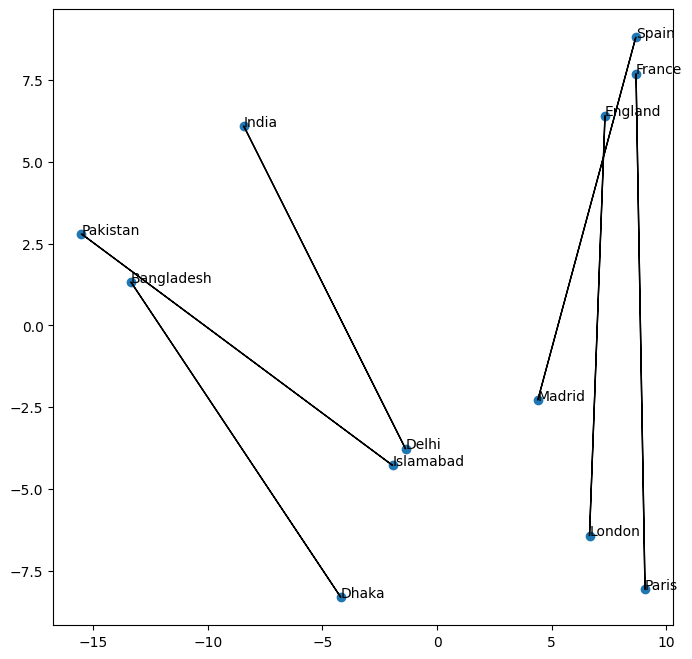

In [421]:
# Examine the vector space

X = ['India', 'Pakistan', 'Bangladesh', 'France', 'England', 'Spain']
Y = ['Delhi', 'Islamabad', 'Dhaka', 'Paris', 'London', 'Madrid']
utils.plot_arrows(X, Y, model.wv)

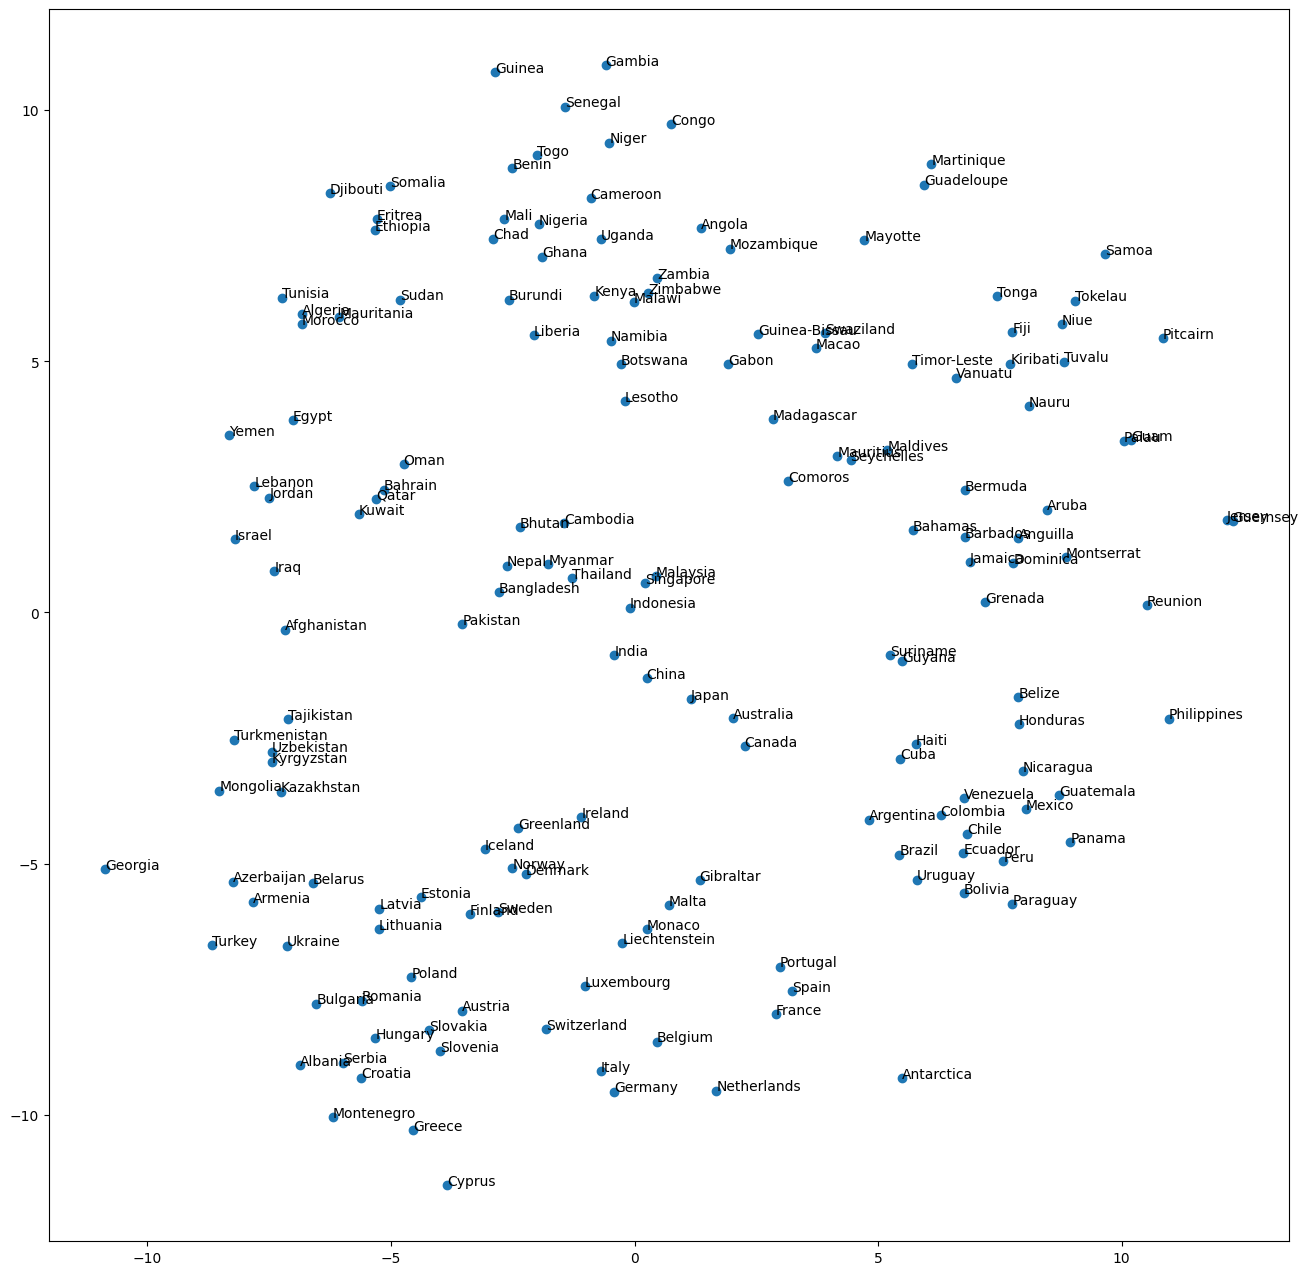

In [422]:
# Visualize vectors for all countries

utils.plot_vectors(countries, model)

## Word Analogies

In [423]:
# India: Ganges -> Brazil: __ ?

model.wv.most_similar(positive=['Ganges', 'Brazil'], negative=['India'])

[('Amazon', 0.44801515340805054),
 ('Lempa', 0.447700172662735),
 ('Plata', 0.44480517506599426),
 ('Paraná', 0.4411579370498657),
 ('Napo', 0.42651188373565674),
 ('Aconcagua', 0.4200591444969177),
 ('Orinoco', 0.40851810574531555),
 ('Llanos', 0.4082527160644531),
 ('jungle', 0.40568920969963074),
 ('Caldera', 0.3976632356643677)]

In [424]:
# America: Washington -> France: __ ?

model.wv.most_similar(positive=['Washington', 'France'], negative=['America'])

[('Nice', 0.4392927885055542),
 ('French', 0.4109540581703186),
 ('Israel', 0.39685550332069397),
 ('Germany', 0.37623411417007446),
 ('Britain', 0.3679819703102112),
 ('Nazi', 0.36000844836235046),
 ('Spain', 0.3556808829307556),
 ('VIII', 0.35021525621414185),
 ('Bern', 0.34968292713165283),
 ('agreement', 0.34836339950561523)]

In [425]:
# India: Hindi -> Germany: __ ?

model.wv.most_similar(positive=['Hindi', 'Germany'], negative=['India'])

[('Romani', 0.4394989311695099),
 ('Salzburg', 0.4092058837413788),
 ('Rusyn', 0.4050486087799072),
 ('Littoral', 0.4049796462059021),
 ('German', 0.399201363325119),
 ('Quechua', 0.3938586413860321),
 ('Aromanian', 0.3882210850715637),
 ('kebab', 0.3777587413787842),
 ('Rusyns', 0.3666601777076721),
 ('dialect', 0.3657534122467041)]

In [426]:
# Save the model

model.save('wiki-countries.w2v')

In [427]:
from gensim.models import KeyedVectors
model = KeyedVectors.load('wiki-countries.w2v')

In [428]:
model